# 🎬 Movie Genre Classification

## Objective
Predict movie genre using plot description using NLP + ML.

## Techniques Used
- Text preprocessing
- TF-IDF Vectorization
- Logistic Regression, Naive Bayes, SVM


In [4]:
import pandas as pd

train_df = pd.read_csv(
    "../data/train_data.txt",
    sep=" ::: ",
    engine="python",
    names=["id", "title", "genre", "plot"]
)

test_df = pd.read_csv(
    "../data/test_data.txt",
    sep=" ::: ",
    engine="python",
    names=["id", "title", "plot"]
)

solution_df = pd.read_csv(
    "../data/test_data_solution.txt",
    sep=" ::: ",
    engine="python",
    names=["id", "title", "genre", "plot"]
)

print("Train shape:", train_df.shape)
train_df.head()

Train shape: (54214, 4)


,id,title,genre,plot
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


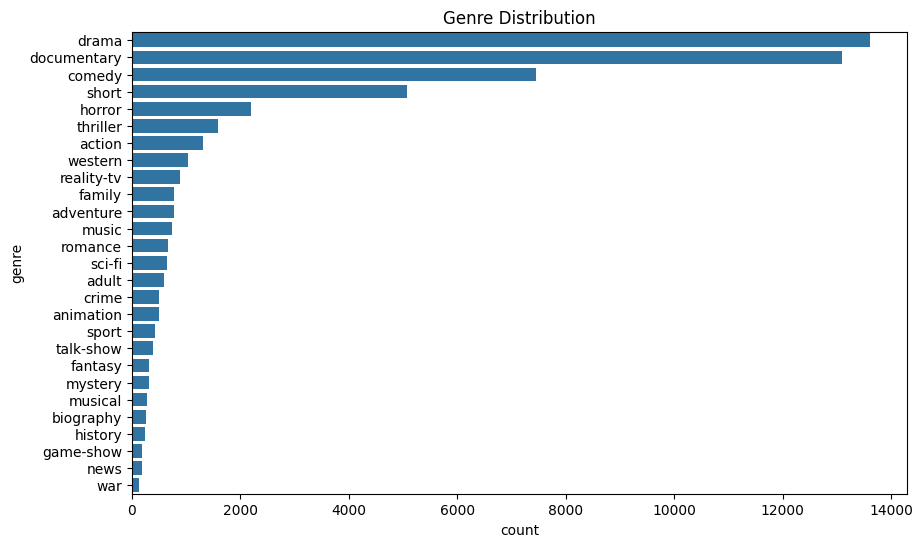

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(y=train_df['genre'], order=train_df['genre'].value_counts().index)
plt.title("Genre Distribution")
plt.show()

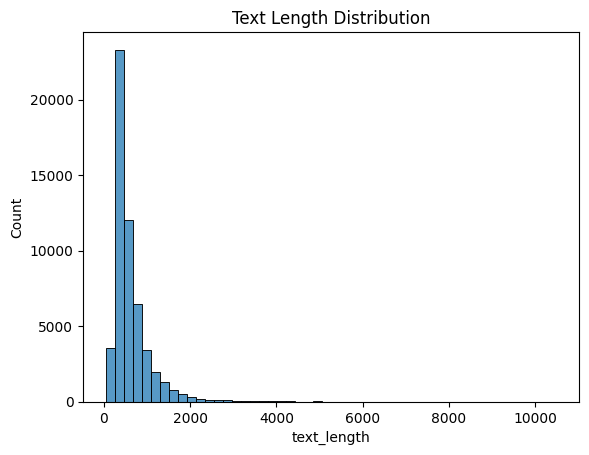

In [6]:
train_df['text_length'] = train_df['plot'].apply(len)

plt.figure()
sns.histplot(train_df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

In [7]:
train_df['genre'].value_counts().head(10)

genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
Name: count, dtype: int64

In [8]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

train_df['clean_plot'] = train_df['plot'].apply(clean_text)
test_df['clean_plot'] = test_df['plot'].apply(clean_text)

train_df[['plot', 'clean_plot']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kaush\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,plot,clean_plot
0,Listening in to a conversation between his doc...,listening conversation doctor parents year old...
1,A brother and sister with a past incestuous re...,brother sister past incestuous relationship cu...
2,As the bus empties the students for their fiel...,bus empties students field trip museum natural...
3,To help their unemployed father make ends meet...,help unemployed father make ends meet edith tw...
4,The film's title refers not only to the un-rec...,film title refers un recovered bodies ground z...


In [9]:
#TFDIF VECTORIZATION
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train = tfidf.fit_transform(train_df['clean_plot'])
y_train = train_df['genre']

X_test = tfidf.transform(test_df['clean_plot'])
y_test = solution_df['genre']

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [11]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [12]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("LR Accuracy:", acc_lr)
print("NB Accuracy:", acc_nb)
print("SVM Accuracy:", acc_svm)

LR Accuracy: 0.5927675276752767
NB Accuracy: 0.5251291512915129
SVM Accuracy: 0.5770479704797048


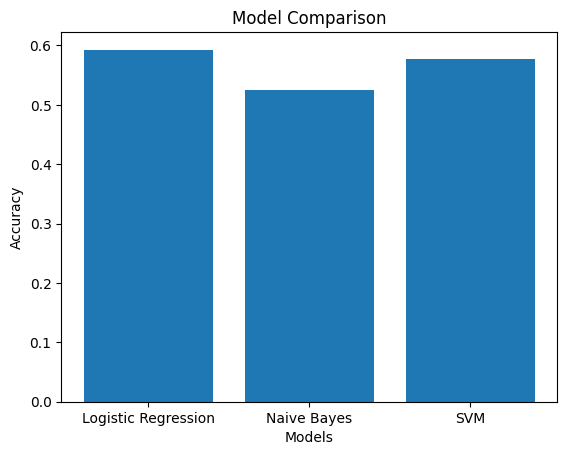

In [14]:
models = ["Logistic Regression", "Naive Bayes", "SVM"]
accuracies = [acc_lr, acc_nb, acc_svm]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

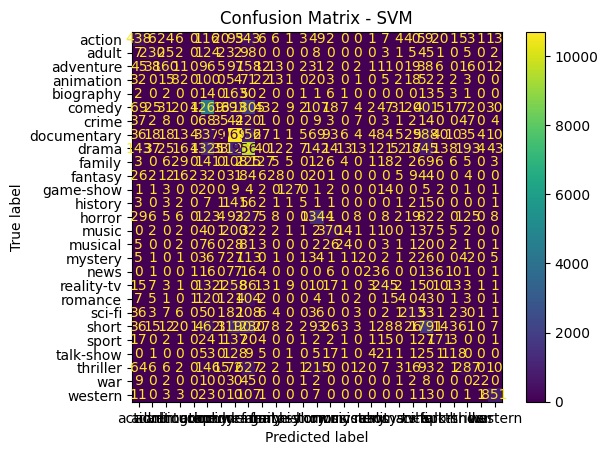

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test)
plt.title("Confusion Matrix - SVM")
plt.show()

<Figure size 2000x1500 with 0 Axes>

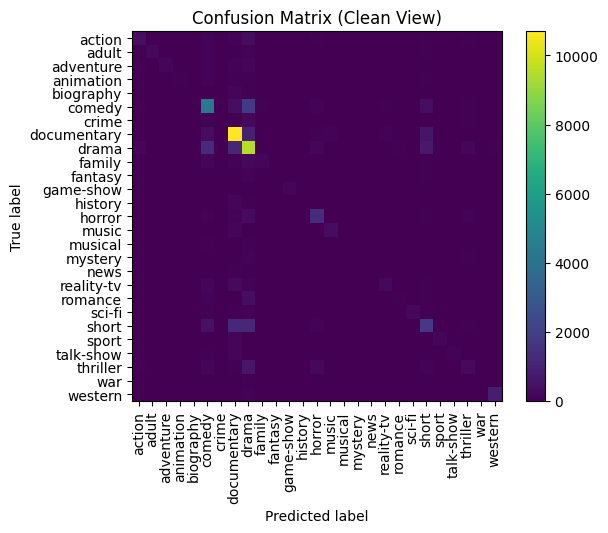

In [17]:
# CLEAN VIEW (REMOVED NUMBERS )
plt.figure(figsize=(20, 15))

disp = ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    y_test,
    xticks_rotation=90,
    include_values=False   # 🔥 removes numbers
)

plt.title("Confusion Matrix (Clean View)")
plt.show()


<Figure size 1200x1000 with 0 Axes>

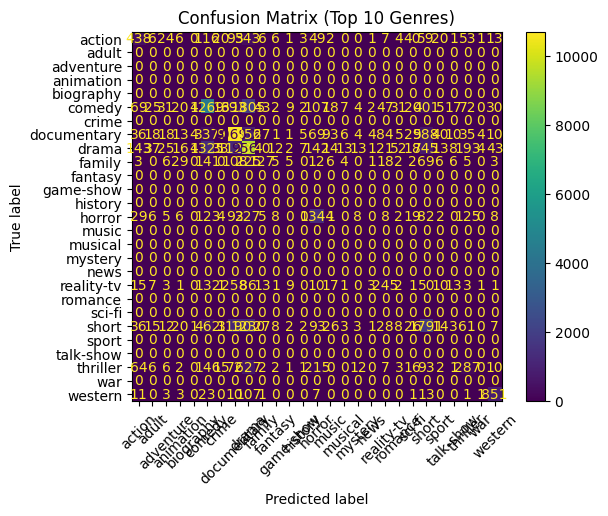

In [22]:
#BEST OPTIMIZED TOP 10 GENRE MATRIX
top_genres = train_df['genre'].value_counts().head(10).index

filtered_idx = y_test.isin(top_genres)

X_test_small = X_test[filtered_idx.values]
y_test_small = y_test[filtered_idx]

plt.figure(figsize=(12,10))

ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test_small,
    y_test_small,
    xticks_rotation=45
)

plt.title("Confusion Matrix (Top 10 Genres)")
plt.show()


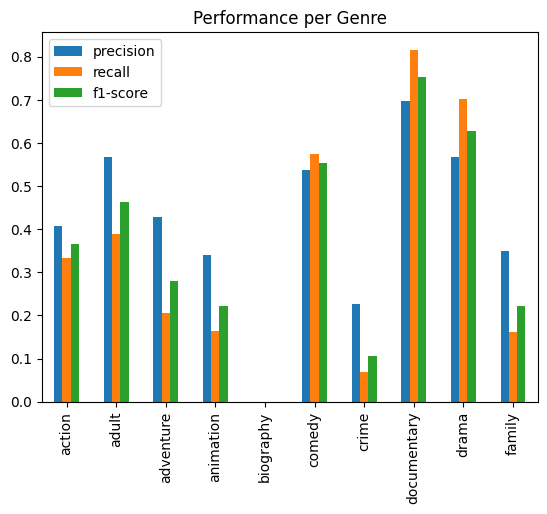

In [23]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred_svm, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report[['precision','recall','f1-score']].head(10).plot(kind='bar')
plt.title("Performance per Genre")
plt.show()

## Conclusion

- SVM performed best among all models.
- Dataset is imbalanced → affects rare genres.
- TF-IDF + ML works well for text classification.

## Future Improvements
- Use Deep Learning (LSTM, BERT)
- Handle class imbalance
- Deploy using Streamlit